In [90]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

### Sample 1

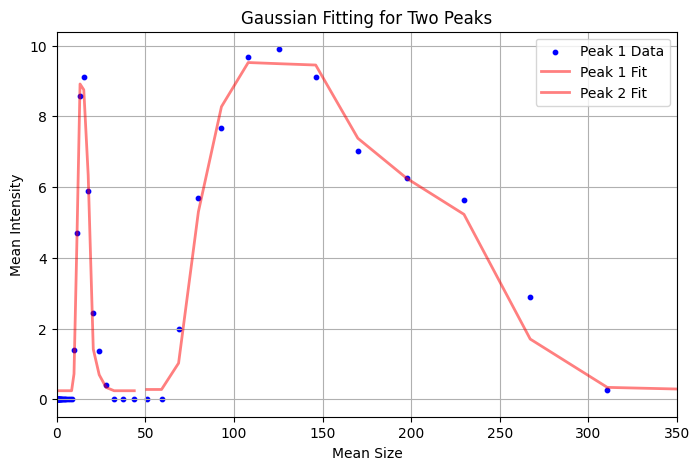

In [81]:
# Import Excel data
file_path = "sample 1 all datas.xlsx"
df = pd.read_excel(file_path, sheet_name="Feuil1")

# SIZE INTENSITY PLOT==========================================================================
#TEST VALUES EXTRACTION
size = df.iloc[:, 0]  # Test 1 sizes
intensity_1 = df.iloc[:, 1]  
intensity_2 = df.iloc[:, 4]  
intensity_3 = df.iloc[:, 7]  
mean_intensity = pd.concat([intensity_1, intensity_2, intensity_3], axis=1).mean(axis=1)

# Supprimer les valeurs NaN
valid_indices = ~np.isnan(size) & ~np.isnan(mean_intensity)
size = size[valid_indices]
mean_intensity = mean_intensity[valid_indices]

# Split data into two peaks
size_peak1 = size.iloc[:34]
size_peak2 = size.iloc[34:]
y_fit1 = np.array([0.240007992, 0.240007992, 0.240007992, 0.240007992, 0.240007992,
                   0.240007992, 0.240007992, 0.240007992, 0.240007992, 0.240007992,
                   0.240007992, 0.240007992, 0.240007992, 0.240007992, 0.240007992,
                   0.240007992, 0.240007992, 0.240007992, 0.240007992, 0.240007992,
                   0.240007992, 0.240007992, 0.240007992, 0.716967358, 4.324626692,
                   8.915101984, 8.750406616, 6.339581501, 1.417980028, 0.691060899,
                   0.333783306, 0.240007992, 0.240007992, 0.240007992])
y_fit2 = np.array([0.275517254, 0.275517254, 1.020511228, 5.302788304, 8.272634701,
                          9.521702493, 9.488126468, 9.45083336, 7.379434852, 6.242799022,
                          5.228423029, 1.70121198, 0.334922012, 0.275517254, 0.275517254,
                          0.275517254, 0.275517254, 0.275517254, 0.275517254, 0.275517254,
                          0.275517254, 0.275517254, 0.275517254, 0.275517254, 0.275517254,
                          0.275517254, 0.275517254, 0.275517254, 0.275517254, 0.275517254,
                          0.275517254, 0.275517254, 0.275517254, 0.275517254, 0.275517254,
                          0.275517254])

#plot les deux fits separement
'''
plt.figure(figsize=(8, 5))
plt.scatter(size, mean_intensity, color='b', s=10, label="Peak 1 Data")
plt.plot(size_peak1, y_fit1, color='r',linestyle='-', alpha=0.5, linewidth=2, label="Peak 1 Fit")
plt.plot(size_peak2, y_fit2, color='r',linestyle='-', alpha=0.5, linewidth=2, label="Peak 2 Fit")

plt.xlabel("Mean Size")
plt.ylabel("Mean Intensity")
plt.title("Gaussian Fitting for Two Peaks")
plt.xlim([0,350])
plt.legend()
plt.grid(True)

plt.show()'''

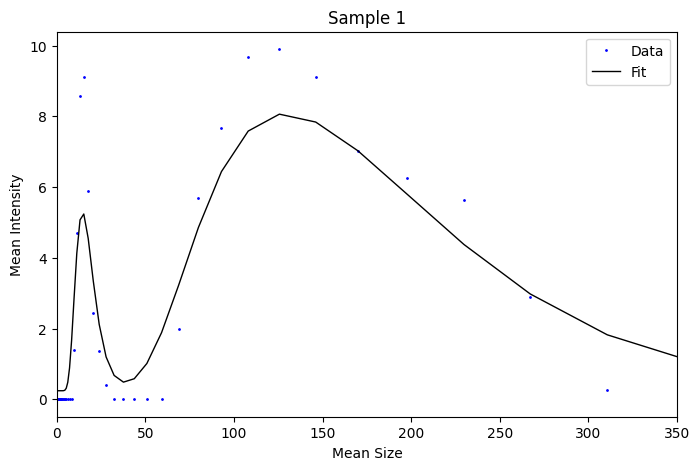

In [105]:
y_combined = np.concatenate([y_fit1, y_fit2])
y_combined = gaussian_filter1d(y_combined, sigma=2)

plt.figure(figsize=(8, 5))
plt.plot(size, mean_intensity, color='b', linestyle = '',marker = 'o',markersize = 1, label="Data")
plt.plot(size, y_combined, color='black', linestyle='-', linewidth=1, label="Fit")

plt.xlabel("Mean Size")
plt.ylabel("Mean Intensity")
plt.title("Sample 1")
plt.xlim([0, 350])
plt.legend()
plt.grid(False)
plt.show()

In [65]:
print(size_peak2)

34       50.79
35       59.07
36       68.69
37       79.88
38       92.89
39      108.00
40      125.60
41      146.10
42      169.90
43      197.60
44      229.80
45      267.20
46      310.70
47      361.30
48      420.20
49      488.70
50      568.30
51      660.90
52      768.50
53      893.80
54     1039.00
55     1209.00
56     1406.00
57     1635.00
58     1901.00
59     2211.00
60     2571.00
61     2990.00
62     3477.00
63     4043.00
64     4702.00
65     5468.00
66     6358.00
67     7394.00
68     8599.00
69    10000.00
Name: Size (d.nm) - Sample 1 [Steady state], dtype: float64
